In [1]:
import lattice_symmetries as ls
import numpy as np
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice
from vmc_amplitude import get_csr_hamiltonian, find_nbd
from scipy import ndimage
from scipy.sparse import csr_matrix
import numpy.typing as npt

In [2]:
lattice = KagomeLattice(2, 3)
system_nosym = HeisenbergJ1J2(
    lattice, J2=1, use_symmetries=False, spin_inversion=None, skip_symmetries_whitelist=True
)
system_sym = HeisenbergJ1J2(
    lattice, J2=1, use_symmetries=True, spin_inversion=None, skip_symmetries_whitelist=True
)

2023-09-15 20:39:05.906 | DEBUG    | heisenberg_hamiltonians:__init__:462 - number_spins=18
2023-09-15 20:39:05.907 | DEBUG    | heisenberg_hamiltonians:__init__:472 - Symmetry group contains 0 elements
2023-09-15 20:39:05.908 | DEBUG    | heisenberg_hamiltonians:__init__:473 - Constructing basis


2023-09-15 20:39:05.923 | DEBUG    | heisenberg_hamiltonians:__init__:481 - Hilbert space dimension is 48620
2023-09-15 20:39:05.930 | WARNING  | heisenberg_hamiltonians:__init__:430 - Symmetries are not tested with KagomeLattice2x3, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-09-15 20:39:05.931 | DEBUG    | heisenberg_hamiltonians:__init__:462 - number_spins=18
2023-09-15 20:39:05.934 | DEBUG    | heisenberg_hamiltonians:__init__:472 - Symmetry group contains 12 elements
2023-09-15 20:39:05.934 | DEBUG    | heisenberg_hamiltonians:__init__:473 - Constructing basis
2023-09-15 20:39:05.950 | DEBUG    | heisenberg_hamiltonians:__init__:481 - Hilbert space dimension is 4160


In [3]:
states = np.random.choice(system_sym.basis.states, size=100, replace=False)
matrix, nbd_states = find_nbd(system_sym.hamiltonian, states)
test_wavefunction = np.random.uniform(-1, 1, size=system_sym.basis.number_states)

assert np.allclose(
    (system_sym.hamiltonian @ test_wavefunction)[system_sym.basis.index(states)],
    matrix @ (test_wavefunction[system_sym.basis.index(nbd_states)]),
)

In [4]:
system_sym_hamiltonian_matrix = get_csr_hamiltonian(system_sym).todense()

In [5]:
system_sym_hamiltonian_matrix[:, 0]

matrix([[12.],
        [ 0.],
        [ 2.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]])

In [7]:
for i, row in enumerate(np.eye(system_sym.basis.number_states)):
    assert np.allclose(system_sym_hamiltonian_matrix[:, i].reshape(-1), system_sym.hamiltonian @ row)

In [32]:
reprs, characters, norms = system_sym.basis.state_info(system_nosym.basis.states)

In [45]:
# FROM: GPT-4
def groupby_sum(values, groups):
    _, indices = np.unique(groups, return_inverse=True)
    
    if np.iscomplexobj(values):
        real_part = np.bincount(indices, weights=values.real)
        imag_part = np.bincount(indices, weights=values.imag)
        result = real_part + 1j * imag_part
    else:
        result = np.bincount(indices, weights=values)
        
    return result
# END FROM


In [34]:
reprs

array([3, 5, 3, 3, 5, 3], dtype=uint64)

In [48]:
system_sym.hamiltonian @ np.array([0., 1.])

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 2; batchedOperatorChunkSize: 1


array([ 5.65685425, -4.        ])

In [5]:
system_sym.basis.state_info(system_sym.canonical_basis.states)

(array([3, 5, 3, 3, 5, 3], dtype=uint64),
 array([1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.-0.j]),
 array([0.5       , 0.70710678, 0.5       , 0.5       , 0.70710678,
        0.5       ]))

In [3]:
nbd_states, coeffs, row_idxs = apply_off_diag_to_basis_states(
    system.hamiltonian, system.basis.states[0:1]
)

In [4]:
nbd_states

array([10,  5], dtype=uint64)

In [5]:
system.basis.state_info(nbd_states)

(array([10,  5], dtype=uint64), array([1.+0.j, 1.+0.j]), array([1., 1.]))

In [6]:
system.basis.states

array([ 3,  5,  6,  9, 10, 12], dtype=uint64)

In [7]:
system.basis.states

array([ 3,  5,  6,  9, 10, 12], dtype=uint64)

<Axes: xlabel='emb_x', ylabel='emb_y'>

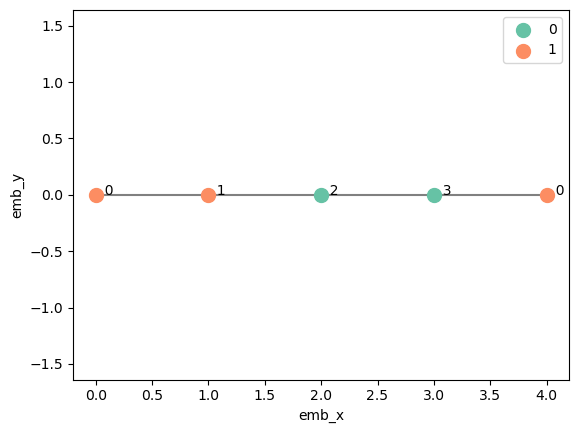

In [8]:
lattice.plot(spins=system.basis.states[0])